# 📊 An Analysis of Sleep, Study Habits, Stress, and Academic Performance Among Students

## Project Overview

This project investigates how various lifestyle and behavioral factors—such as sleep, stress, study habits, and physical activity—relate to students' academic performance (measured by GPA). By combining and analyzing multiple datasets, we aim to identify patterns and relationships that may influence student success.

---

## Introduction

College students routinely face competing pressures to study longer, sleep less, and manage escalating levels of academic stress. The popular belief that sacrificing sleep for extra study hours improves performance carries real costs: sleep deprivation impairs memory consolidation, cognitive flexibility, and stress regulation—all of which undermine academic success.

This project investigates the relationships among sleep duration, study habits, stress levels, and GPA using two publicly available Kaggle datasets: a Student Stress, Sleep, and Screen Time dataset and a Student Lifestyle and Academic Performance dataset. The two were merged by student ID to create a unified dataset capturing both behavioral factors and academic outcomes. Rather than treating these variables in isolation, we model them jointly to understand their relative contributions.

---

## Background and Related Work

Prior research consistently links sleep and stress to academic outcomes. Hershner & Chervin (2014) found that poor sleep quality and insufficient duration are prevalent among college students and associated with lower grades. Curcio, Ferrara, & De Gennaro (2006) linked sleep loss to deficits in attention and memory consolidation. On the stress side, Pascoe, Hetrick, & Parker (2020) found anxiety and academic pressure to be robust negative predictors of performance. Hartmann & Prichard (2018) found that sleep quality predicted GPA more strongly than quantity alone. Across this literature, study hours show the most consistent association with GPA, while the independent contributions of sleep and stress vary by sample and measurement approach.

---

## 📁 Datasets Used

### 1. Student Stress, Sleep, and Screen Time Dataset
This dataset contains detailed information about students' daily habits and stress-related factors, including:

- `student_id`: Unique identifier for each student  
- `age`: Age of the student  
- `gender`: Gender of the student  
- `sleep_hours`: Average hours of sleep per day  
- `screen_time_hours`: Daily screen time  
- `stress_level`: Self-reported stress level (Low, Medium, High)  
- `study_hours`: Hours spent studying  
- `physical_activity`: Level of physical activity  
- `caffeine_intake`: Daily caffeine consumption  
- `academic_pressure`: Perceived academic pressure  

This dataset helps us understand behavioral and mental health factors that may influence academic performance.

---

### 2. Student Lifestyle and Academic Performance Dataset
This dataset focuses on students’ time allocation and academic outcomes:

- `Student_ID`: Unique identifier (merged with `student_id`)  
- `Study_Hours_Per_Day`: Daily study time  
- `Extracurricular_Hours_Per_Day`: Time spent on extracurricular activities  
- `Sleep_Hours_Per_Day`: Sleep duration  
- `Social_Hours_Per_Day`: Time spent socializing  
- `Physical_Activity_Hours_Per_Day`: Time spent exercising  
- `GPA`: Academic performance metric  
- `Stress_Level`: Reported stress level

This dataset provides key information about how students distribute their time and how it relates to GPA.

---

## 🔗 Data Integration

The two datasets were merged using the student ID (`student_id` / `Student_ID`) to create a comprehensive dataset. This combined dataset allows us to analyze both:

- Lifestyle habits  
- Academic outcomes  

in a unified framework.

---

## 🎯 Objective

The main goal of this project is to explore and understand:

- Which factors are most associated with GPA  
- Whether stress significantly impacts academic performance  
- How lifestyle habits (sleep, study time, activity) influence success  

Through exploratory data analysis, we aim to uncover meaningful insights that could help improve student performance and well-being.

In [ ]:
import pandas as pd

df1 = pd.read_csv("student_stress_sleep_screen.csv")
df2 = pd.read_csv("student_lifestyle_dataset.csv")

df1.head()

,student_id,age,gender,sleep_hours,screen_time_hours,stress_level,study_hours,physical_activity,caffeine_intake,academic_pressure
0,S001,22,Female,5.9,2.7,Medium,7.4,Yes,3,High
1,S002,25,Male,5.9,7.6,High,4.6,No,2,Low
2,S003,23,Male,8.0,3.2,Low,2.0,Yes,3,High
3,S004,22,Female,7.8,11.4,Medium,4.4,Yes,3,High
4,S005,20,Other,6.0,2.9,Medium,6.7,No,0,High


In [ ]:
df2.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [ ]:
def clean_cols(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

df1 = clean_cols(df1)
df2 = clean_cols(df2)

In [ ]:
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         500 non-null    object 
 1   age                500 non-null    int64  
 2   gender             500 non-null    object 
 3   sleep_hours        500 non-null    float64
 4   screen_time_hours  500 non-null    float64
 5   stress_level       500 non-null    object 
 6   study_hours        500 non-null    float64
 7   physical_activity  500 non-null    object 
 8   caffeine_intake    500 non-null    int64  
 9   academic_pressure  500 non-null    object 
dtypes: float64(3), int64(2), object(5)
memory usage: 39.2+ KB


,age,sleep_hours,screen_time_hours,study_hours,caffeine_intake
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,21.532000,6.547200,7.109600,5.019000,1.98000
std,2.244784,1.436098,2.906366,1.759856,1.39409
min,18.000000,4.000000,2.000000,2.000000,0.00000
25%,20.000000,5.300000,4.575000,3.500000,1.00000
50%,22.000000,6.500000,7.300000,5.000000,2.00000
75%,23.000000,7.800000,9.500000,6.600000,3.00000
max,25.000000,9.000000,12.000000,8.000000,4.00000


In [ ]:
df2.info()
df2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       2000 non-null   int64  
 1   study_hours_per_day              2000 non-null   float64
 2   extracurricular_hours_per_day    2000 non-null   float64
 3   sleep_hours_per_day              2000 non-null   float64
 4   social_hours_per_day             2000 non-null   float64
 5   physical_activity_hours_per_day  2000 non-null   float64
 6   gpa                              2000 non-null   float64
 7   stress_level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


,student_id,study_hours_per_day,extracurricular_hours_per_day,sleep_hours_per_day,social_hours_per_day,physical_activity_hours_per_day,gpa
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


In [ ]:
# clean column names
df1.columns = df1.columns.str.lower()
df2.columns = df2.columns.str.lower()

# convert df2 ids to match df1 format (S001 style)
df2["student_id"] = df2["student_id"].apply(lambda x: f"S{int(x):03d}")

## Data Merging

We combined two datasets containing student information:

- `student_stress_sleep_screen.csv`
- `student_lifestyle_dataset.csv`

The datasets were merged using the `student_id` column as a key. Before merging, we ensured that both datasets had matching column names and data types for the ID variable.

After merging:
- Duplicate columns (e.g., stress level) were handled
- Columns were standardized (lowercase naming)
- The final dataset contained variables related to:
  - academic performance (GPA)
  - lifestyle habits (sleep, study hours, screen time)
  - health and stress indicators

This merged dataset allows us to analyze how lifestyle and stress factors relate to academic performance.

In [ ]:
df = pd.merge(df1, df2, on="student_id", how="inner")

print(df.shape)
df.head()

(500, 17)


,student_id,age,gender,sleep_hours,screen_time_hours,stress_level_x,study_hours,physical_activity,caffeine_intake,academic_pressure,study_hours_per_day,extracurricular_hours_per_day,sleep_hours_per_day,social_hours_per_day,physical_activity_hours_per_day,gpa,stress_level_y
0,S001,22,Female,5.9,2.7,Medium,7.4,Yes,3,High,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,S002,25,Male,5.9,7.6,High,4.6,No,2,Low,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,S003,23,Male,8.0,3.2,Low,2.0,Yes,3,High,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,S004,22,Female,7.8,11.4,Medium,4.4,Yes,3,High,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,S005,20,Other,6.0,2.9,Medium,6.7,No,0,High,8.1,0.6,6.5,2.2,6.6,3.51,High


In [ ]:
df = df.rename(columns={
    "stress_level_x": "stress_level"
})

df = df.drop(columns=["stress_level_y"])

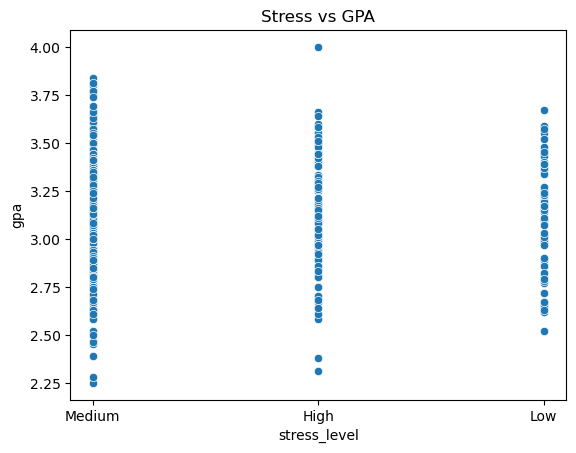

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="stress_level", y="gpa", data=df)
plt.title("Stress vs GPA")
plt.show()

## Stress vs GPA

This scatter plot shows the relationship between stress level (categorical) and GPA.

### Insights:
- GPA distributions across stress levels (Low, Medium, High) appear very similar
- There is no strong visible trend suggesting that higher stress leads to lower GPA
- Students with all stress levels achieve a wide range of GPAs

### Interpretation:
Stress level alone does not appear to be a strong predictor of academic performance in this dataset.

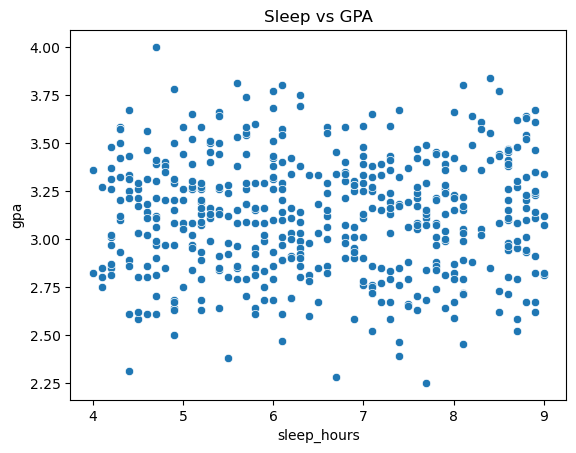

In [ ]:
sns.scatterplot(x="sleep_hours", y="gpa", data=df)
plt.title("Sleep vs GPA")
plt.show()

## Sleep vs GPA

This scatter plot examines the relationship between sleep hours and GPA.

### Insights:
- Data points are widely scattered
- There is no clear upward or downward trend
- Students with both low and high sleep hours achieve similar GPAs

### Interpretation:
Sleep does not show a strong linear relationship with GPA. While sleep is important for health, its direct impact on GPA is not clearly visible in this dataset.

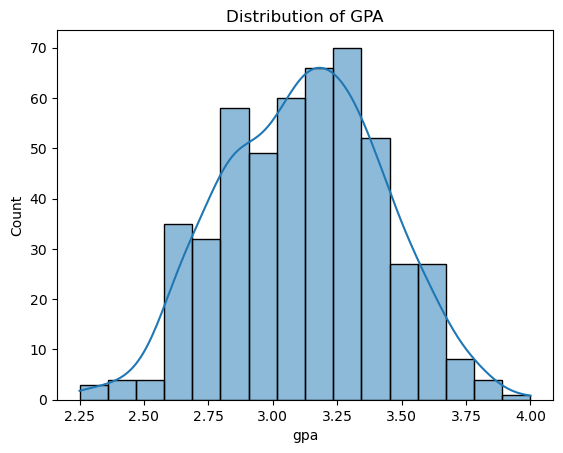

In [ ]:
sns.histplot(df["gpa"], kde=True)
plt.title("Distribution of GPA")
plt.show()

## Distribution of GPA

This histogram shows the distribution of GPA across all students.

### Insights:
- The distribution is approximately normal
- Most GPAs fall between 2.8 and 3.5
- Very few extreme low or high GPA values

### Interpretation:
The GPA distribution suggests that most students perform within a relatively narrow academic range, with few outliers.

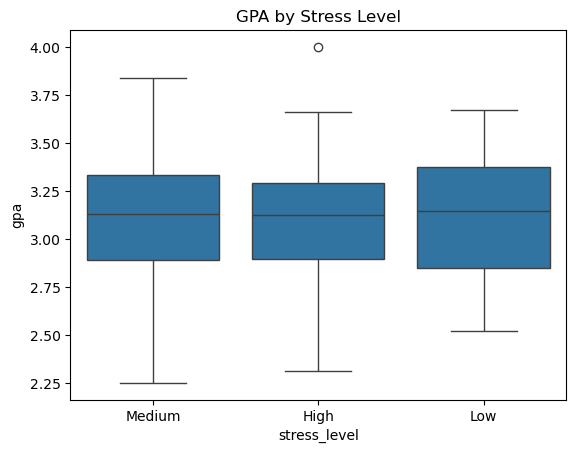

In [ ]:
sns.boxplot(x="stress_level", y="gpa", data=df)
plt.title("GPA by Stress Level")
plt.show()

## GPA by Stress Level

This boxplot compares GPA distributions across stress levels.

### Insights:
- Median GPA is very similar across all stress levels
- Interquartile ranges overlap significantly
- No group shows a clearly higher or lower GPA

### Interpretation:
There is little evidence that stress level significantly impacts GPA when comparing distributions.

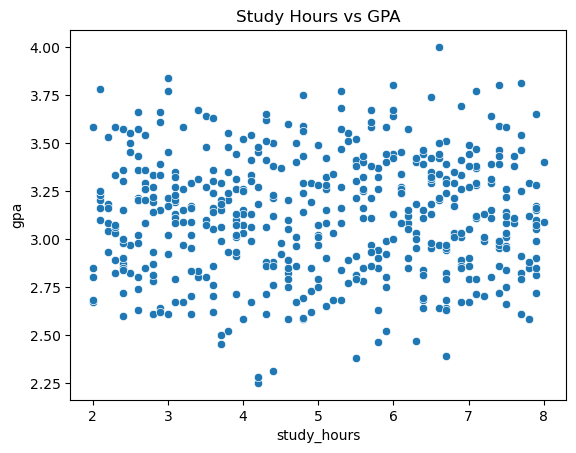

In [ ]:
sns.scatterplot(x="study_hours", y="gpa", data=df)
plt.title("Study Hours vs GPA")
plt.show()

## Study Hours vs GPA

This scatter plot shows the relationship between study hours and GPA.

### Insights:
- Slight positive trend: higher study hours may be associated with slightly higher GPA
- However, the relationship is weak and noisy
- Students with lower study hours can still achieve high GPAs

### Interpretation:
Study time may have some influence on GPA, but it is not the only factor determining academic performance.

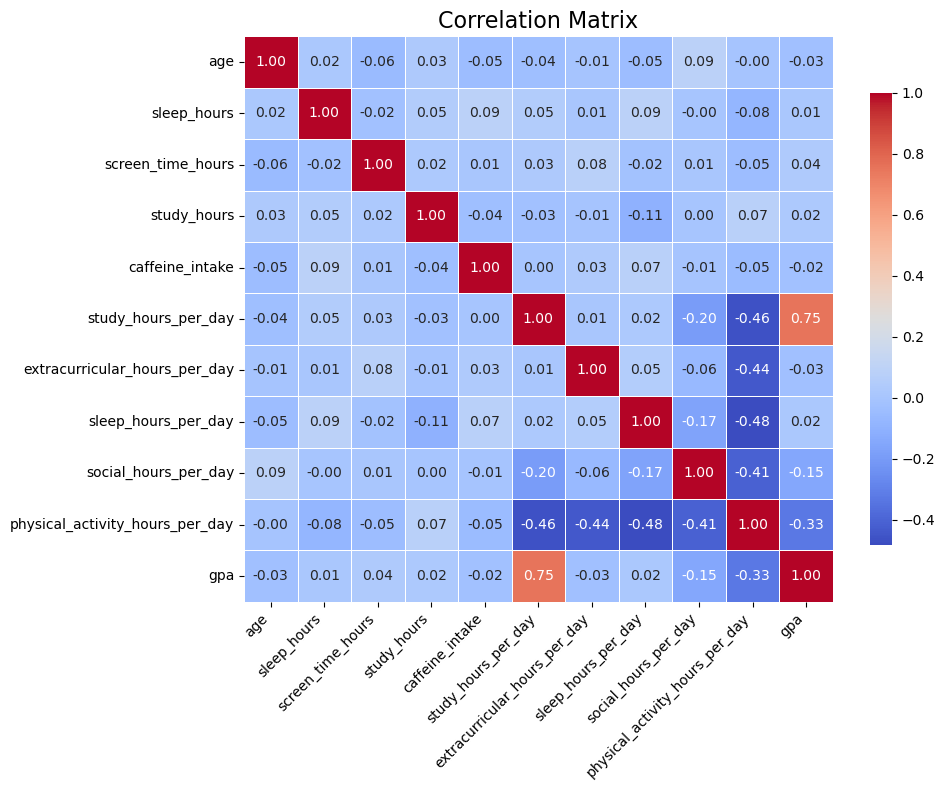

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# correlation
corr = df.corr(numeric_only=True)

# make plot bigger
plt.figure(figsize=(10, 8))

# clean heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",              # round to 2 decimals
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

## Correlation Matrix

The correlation matrix summarizes relationships between numerical variables.

### Key Findings:
- Study hours per day shows the strongest positive correlation with GPA
- Physical activity shows a negative correlation with GPA
- Most other variables have weak correlations with GPA

### Interpretation:
No single variable strongly explains GPA. Academic performance is likely influenced by a combination of multiple factors.

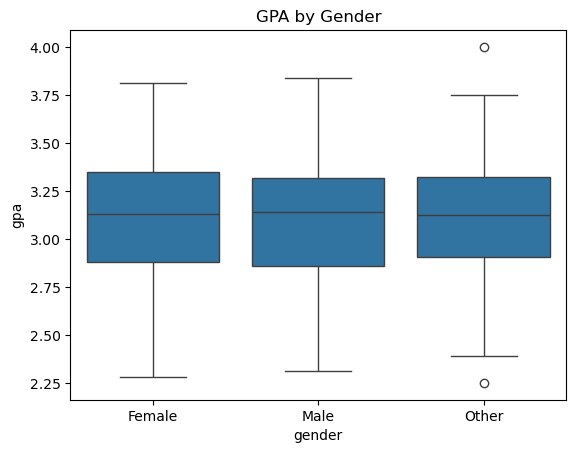

In [ ]:
sns.boxplot(x="gender", y="gpa", data=df)
plt.title("GPA by Gender")
plt.show()

## GPA by Gender

This boxplot compares GPA distributions across gender groups.

### Insights:
- Median GPA is similar across all genders
- Distributions overlap heavily
- No group consistently outperforms others

### Interpretation:
There is no clear evidence of GPA differences based on gender in this dataset.

## Conclusion

From our exploratory data analysis, we find that:

- Most variables (sleep, stress, screen time) show weak relationships with GPA
- Study hours show the strongest (though still moderate) positive relationship with GPA
- Stress level does not appear to significantly impact academic performance
- GPA distributions are consistent across gender groups
- Academic performance is likely influenced by multiple interacting factors rather than a single dominant variable

### Overall Takeaway:
There is no single lifestyle factor that strongly determines GPA. Instead, academic performance appears to be the result of a combination of habits, behaviors, and possibly external factors not captured in this dataset.

# Section 2 - Hypothesis Testing

This part is for the hypothesis testing section of the project. Next of the EDA, here I am using the same merged data and checking some of the patterns more formally.

The tests I am going to use are,

- Pearson correlation for numerical variables
- two-sample t-test for comparing two groups
- ANOVA for comparing more than two groups
- chi-square test of independence for categorical variables

Let alpha = 0.05.

## Load and Merge the Data

This is basically the same merge from the EDA part. I kept it here so this notebook can run by itself.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
df1 = pd.read_csv("student_stress_sleep_screen.csv")
df2 = pd.read_csv("student_lifestyle_dataset.csv")

df1.columns = df1.columns.str.strip().str.lower()
df2.columns = df2.columns.str.strip().str.lower()

df2["student_id"] = df2["student_id"].apply(lambda x: f"S{int(x):03d}")

df = pd.merge(df1, df2, on="student_id", how="inner", suffixes=("_x", "_y"))
df = df.rename(columns={"stress_level_x": "stress_level"})
df = df.drop(columns=["stress_level_y"])

df.shape

(500, 16)

The merged data has 500 rows. I use `gpa` as the response variable for the GPA tests. For the categorical tests, I use variables from the stress/sleep/screen dataset such as `physical_activity`, `stress_level`, `gender`, and `academic_pressure`.

In [ ]:
df[["gpa", "sleep_hours", "study_hours", "screen_time_hours", "study_hours_per_day", "sleep_hours_per_day", "social_hours_per_day", "physical_activity_hours_per_day"]].describe()

,gpa,sleep_hours,study_hours,screen_time_hours,study_hours_per_day,sleep_hours_per_day,social_hours_per_day,physical_activity_hours_per_day
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,3.118960,6.547200,5.019000,7.109600,7.475000,7.488200,2.79880,4.226200
std,0.306514,1.436098,1.759856,2.906366,1.498561,1.457123,1.69274,2.610902
min,2.250000,4.000000,2.000000,2.000000,5.000000,5.000000,0.00000,0.100000
25%,2.887500,5.300000,3.500000,4.575000,6.100000,6.200000,1.40000,2.100000
50%,3.130000,6.500000,5.000000,7.300000,7.400000,7.600000,2.70000,4.000000
75%,3.330000,7.800000,6.600000,9.500000,8.800000,8.800000,4.20000,5.925000
max,4.000000,9.000000,8.000000,12.000000,10.000000,10.000000,6.00000,13.000000


## 1. Correlation Analysis

According to what we did in project proposal, I will research correlations between lifestyle variables and GPA. This also connects to the regression/correlation material from class.

For this part:

- Null hypothesis: the correlation between the variable and GPA is 0.
- Alternative hypothesis: the correlation between the variable and GPA is not 0.

In [ ]:
num_cols = [
    "gpa",
    "sleep_hours",
    "study_hours",
    "screen_time_hours",
    "caffeine_intake",
    "study_hours_per_day",
    "sleep_hours_per_day",
    "social_hours_per_day",
    "physical_activity_hours_per_day"
]

corr = df[num_cols].corr()
corr["gpa"].sort_values(ascending=False)

gpa                                1.000000
study_hours_per_day                0.752254
screen_time_hours                  0.037554
study_hours                        0.021157
sleep_hours_per_day                0.017059
sleep_hours                        0.009213
caffeine_intake                   -0.020309
social_hours_per_day              -0.150200
physical_activity_hours_per_day   -0.330217
Name: gpa, dtype: float64

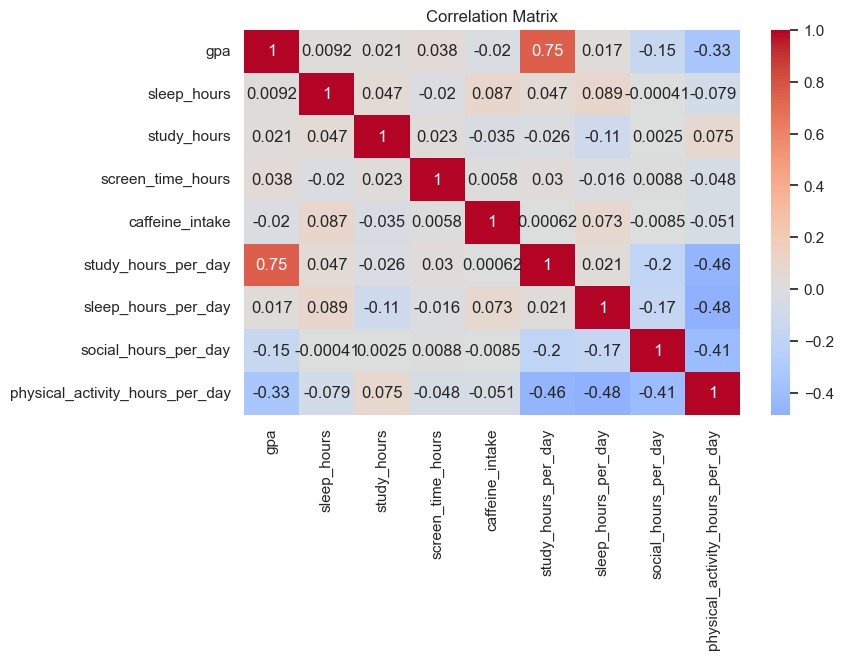

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that `study_hours_per_day` has the strongest positive relationship with GPA. The negative relationships that stand out are `physical_activity_hours_per_day` and `social_hours_per_day`.

To check the p-values, I tested the main variables separately below.

In [ ]:
stats.pearsonr(df["study_hours_per_day"], df["gpa"])

PearsonRResult(statistic=np.float64(0.7522544656743313), pvalue=np.float64(2.7493396240951963e-92))

For `study_hours_per_day`, the correlation is about 0.752 and the p-value is less than 0.001. Since the p-value is below 0.05, I would reject the null hypothesis. Study hours per day seems to have a statistically significant positive relationship with GPA.

In [ ]:
stats.pearsonr(df["sleep_hours"], df["gpa"])

PearsonRResult(statistic=np.float64(0.009212506338270657), pvalue=np.float64(0.8371919064643154))

For `sleep_hours`, the correlation is about 0.009 and the p-value is about 0.837. This is not significant. Even though sleep is important in real life, this dataset does not show a clear linear relationship between sleep hours and GPA.

In [ ]:
stats.pearsonr(df["social_hours_per_day"], df["gpa"])

PearsonRResult(statistic=np.float64(-0.15020011808748995), pvalue=np.float64(0.0007535844693183668))

For `social_hours_per_day`, the correlation is about -0.150 and the p-value is less than 0.001. This is statistically significant, but the correlation is still pretty small. I would describe it as a weak negative relationship.

In [ ]:
stats.pearsonr(df["physical_activity_hours_per_day"], df["gpa"])

PearsonRResult(statistic=np.float64(-0.33021691812541404), pvalue=np.float64(3.4816281682309195e-14))

For `physical_activity_hours_per_day`, the correlation is about -0.330 and the p-value is less than 0.001. This is a moderate negative relationship in this dataset. This does not mean physical activity causes lower GPA, but it is a pattern that shows up in the data.

## 2. Two-Sample t-Test: Healthy Sleep Group

The proposal mentions comparing students with healthier sleep habits. I defined healthy sleep as 7 to 9 hours, which is a simple and common cutoff.

The two groups are:

- 7-9 hours of sleep
- other sleep amounts

- Null hypothesis: the two groups have the same mean GPA.
- Alternative hypothesis: the two groups have different mean GPAs.

In [ ]:
df["sleep_group"] = np.where(df["sleep_hours"].between(7, 9), "7-9 hours", "other")
df.groupby("sleep_group")["gpa"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
sleep_group,,,,
7-9 hours,215,3.116140,3.15,0.311338
other,285,3.121088,3.12,0.303357


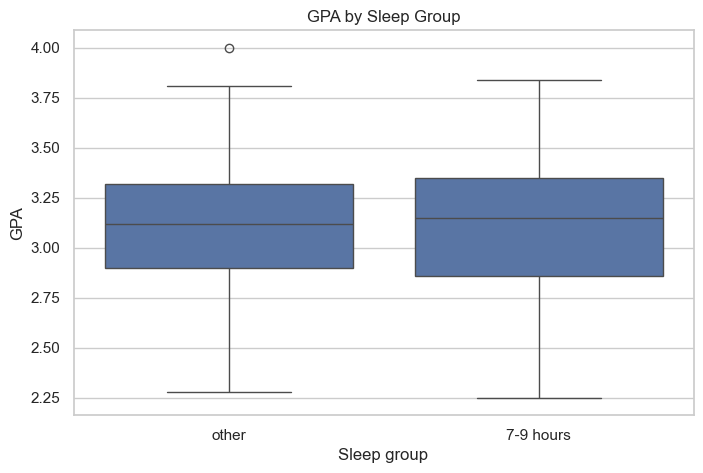

In [ ]:
sns.boxplot(data=df, x="sleep_group", y="gpa")
plt.title("GPA by Sleep Group")
plt.xlabel("Sleep group")
plt.ylabel("GPA")
plt.show()

In [ ]:
g1 = df[df["sleep_group"] == "7-9 hours"]["gpa"]
g2 = df[df["sleep_group"] == "other"]["gpa"]

stats.ttest_ind(g1, g2, equal_var=False)

TtestResult(statistic=np.float64(-0.17788884388205348), pvalue=np.float64(0.8588895113357131), df=np.float64(454.5966527951905))

The average GPA for the 7-9 hour group is about 3.116. The average GPA for the other group is about 3.121.

The p-value is about 0.859, which is much larger than 0.05. So I fail to reject the null hypothesis. Based on this test, the healthy sleep group does not have a significantly different average GPA.

## 3. ANOVA: Stress Level and GPA

The EDA showed that GPA looked similar across Low, Medium, and High stress. Since there are three groups, I used ANOVA.

- Null hypothesis: the mean GPA is the same for all stress levels.
- Alternative hypothesis: at least one stress level has a different mean GPA.

In [ ]:
df.groupby("stress_level")["gpa"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
stress_level,,,,
High,102,3.120980,3.125,0.305982
Low,60,3.109667,3.145,0.305841
Medium,338,3.120000,3.130,0.307670


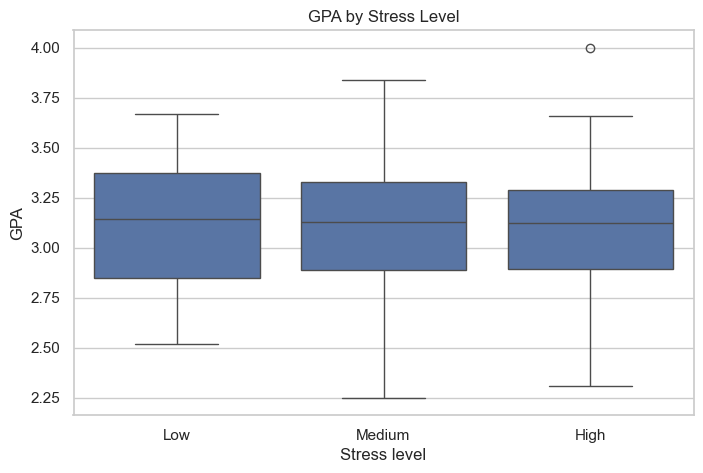

In [ ]:
sns.boxplot(data=df, x="stress_level", y="gpa", order=["Low", "Medium", "High"])
plt.title("GPA by Stress Level")
plt.xlabel("Stress level")
plt.ylabel("GPA")
plt.show()

In [ ]:
low = df[df["stress_level"] == "Low"]["gpa"]
med = df[df["stress_level"] == "Medium"]["gpa"]
high = df[df["stress_level"] == "High"]["gpa"]

stats.f_oneway(low, med, high)

F_onewayResult(statistic=np.float64(0.031616318984275145), pvalue=np.float64(0.9688801994587415))

The mean GPAs are almost the same:

- Low stress: about 3.110
- Medium stress: about 3.120
- High stress: about 3.121

The ANOVA p-value is about 0.969. Since this is greater than 0.05, I fail to reject the null hypothesis. I do not see evidence that GPA differs by stress level.

## 4. Two-Sample t-Test: Physical Activity Yes/No

This is a smaller extra check because the EDA included physical activity. Here I use the Yes/No physical activity variable from the first dataset.

- Null hypothesis: students who answered Yes and No have the same mean GPA.
- Alternative hypothesis: students who answered Yes and No have different mean GPAs.

In [ ]:
df.groupby("physical_activity")["gpa"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
physical_activity,,,,
No,266,3.103158,3.135,0.302098
Yes,234,3.136923,3.130,0.311130


In [ ]:
yes = df[df["physical_activity"] == "Yes"]["gpa"]
no = df[df["physical_activity"] == "No"]["gpa"]

stats.ttest_ind(yes, no, equal_var=False)

TtestResult(statistic=np.float64(1.2273972228891783), pvalue=np.float64(0.2202676496492), df=np.float64(485.89211189598))

The p-value is about 0.220, so this test is not significant at alpha = 0.05. The Yes/No physical activity variable does not show a clear difference in average GPA.

This is a little different from `physical_activity_hours_per_day`, which had a negative correlation with GPA. The number of hours seems more informative than the simple Yes/No variable.

## 5. Chi-Square Test: Physical Activity and Stress Level

The chi-square test of independence is useful when both variables are categorical. Here I tested whether `physical_activity` and `stress_level` are related.

- Null hypothesis: physical activity and stress level are independent.
- Alternative hypothesis: physical activity and stress level are associated.

In [ ]:
activity_stress = pd.crosstab(df["physical_activity"], df["stress_level"])
activity_stress

stress_level,High,Low,Medium
physical_activity,,,
No,56,34,176
Yes,46,26,162


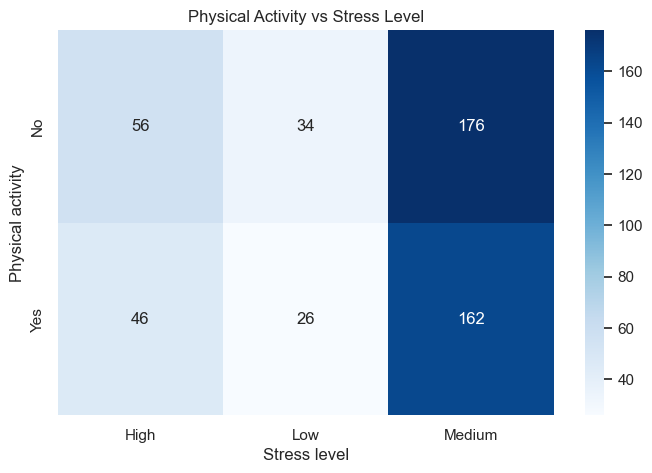

In [ ]:
sns.heatmap(activity_stress, annot=True, fmt="d", cmap="Blues")
plt.title("Physical Activity vs Stress Level")
plt.xlabel("Stress level")
plt.ylabel("Physical activity")
plt.show()

In [ ]:
stats.chi2_contingency(activity_stress)

Chi2ContingencyResult(statistic=np.float64(0.5813215734991974), pvalue=np.float64(0.7477692882525016), dof=2, expected_freq=array([[ 54.264,  31.92 , 179.816],
       [ 47.736,  28.08 , 158.184]]))

The chi-square p-value is about 0.748. Since this is greater than 0.05, I fail to reject the null hypothesis. In this dataset, I do not see evidence that physical activity Yes/No is related to stress level.

## 6. Chi-Square Test: Gender and Academic Pressure

I also checked whether academic pressure looks different across gender groups.

- Null hypothesis: gender and academic pressure are independent.
- Alternative hypothesis: gender and academic pressure are associated.

In [ ]:
gender_pressure = pd.crosstab(df["gender"], df["academic_pressure"])
gender_pressure

academic_pressure,High,Low,Medium
gender,,,
Female,52,52,57
Male,54,60,57
Other,55,61,52


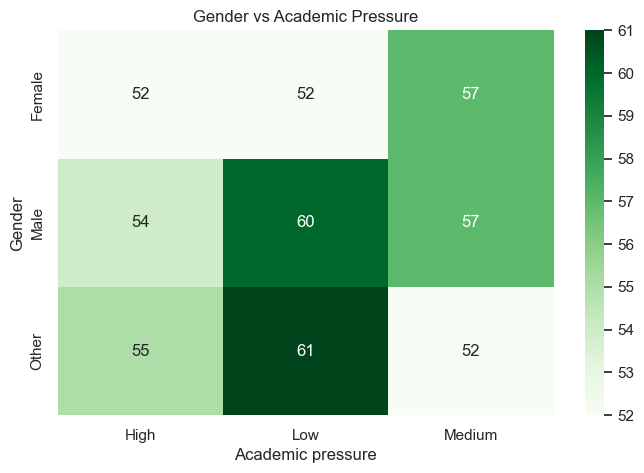

In [ ]:
sns.heatmap(gender_pressure, annot=True, fmt="d", cmap="Greens")
plt.title("Gender vs Academic Pressure")
plt.xlabel("Academic pressure")
plt.ylabel("Gender")
plt.show()

In [ ]:
stats.chi2_contingency(gender_pressure)

Chi2ContingencyResult(statistic=np.float64(0.9283352059048409), pvalue=np.float64(0.9204609414676163), dof=4, expected_freq=array([[51.842, 55.706, 53.452],
       [55.062, 59.166, 56.772],
       [54.096, 58.128, 55.776]]))

The chi-square p-value is about 0.920. This is not significant at alpha = 0.05. Based on this test, I do not see evidence that academic pressure is distributed differently by gender.

## Hypothesis Testing Summary

Overall, `study_hours_per_day` seems to be the strongest variable related to GPA. It has a clear positive correlation with GPA.

The tests for sleep and stress were not significant. The 7-9 hour sleep group did not have a different average GPA, and the ANOVA did not show a GPA difference across stress levels.

The categorical tests were also not significant. Physical activity Yes/No did not seem related to stress level, and gender did not seem related to academic pressure.

So for this section, my main conclusion is that the data gives more support for study time being related to GPA than for sleep, stress, or the categorical lifestyle variables having strong relationships in these simple tests. These tests do not prove cause and effect.

# 📈 Regression Modeling

In this section we model **GPA** as a function of students' daily time-use using the
Student Lifestyle dataset (the only dataset containing GPA). We fit a set of linear
regression models, evaluate them with formal diagnostics, interpret the coefficients,
and summarize the findings in a written Results section.

> **Note on data:** Because the five daily-activity variables sum to a fixed 24 hours,
> they are *compositional*. We therefore drop **extracurricular hours** as a reference
> category, so each coefficient represents the effect of reallocating one hour *out of
> extracurricular time and into* that activity.

## 1. Model Specification & Fitting

We fit three nested models to test whether added complexity improves explanatory power:
**M1** (study hours only), **M2** (four activities, extracurricular as reference), and
**M3** (M2 plus a categorical stress-level control). We compare them on R², adjusted R²,
and AIC, then carry the best model forward.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load + clean the lifestyle dataset (same cleaning as clean_cols above).
# Self-contained, so this section runs regardless of which earlier cells were executed.
life = pd.read_csv("student_lifestyle_dataset.csv")
life.columns = life.columns.str.strip().str.lower().str.replace(" ", "_")

PREDS = ["study_hours_per_day", "sleep_hours_per_day",
         "social_hours_per_day", "physical_activity_hours_per_day"]
print("n =", len(life), "| has gpa:", "gpa" in life.columns)

n = 2000 | has gpa: True


In [ ]:
m1 = smf.ols("gpa ~ study_hours_per_day", data=life).fit()
m2 = smf.ols("gpa ~ " + " + ".join(PREDS), data=life).fit()
m3 = smf.ols("gpa ~ " + " + ".join(PREDS) + " + C(stress_level)", data=life).fit()

comparison = pd.DataFrame({
    "Model": ["M1 (study only)", "M2 (4 activities)", "M3 (+ stress)"],
    "Predictors": [1, 4, 6],
    "R2":     [m1.rsquared,     m2.rsquared,     m3.rsquared],
    "Adj_R2": [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    "AIC":    [m1.aic,          m2.aic,          m3.aic],
}).round(4)
comparison

,Model,Predictors,R2,Adj_R2,AIC
0,M1 (study only),1,0.5394,0.5392,-705.5010
1,M2 (4 activities),4,0.5410,0.5400,-706.1322
2,M3 (+ stress),6,0.5418,0.5404,-705.5456


### Model comparison

Moving from M1 to M2 to M3 produces almost no change in adjusted R² (0.539 → 0.540 →0.540): adding sleep, social, and physical-activity hours, and then a stress-level control, does not meaningfully improve fit over study hours alone. M2 has the lowest AIC(−706.1), so it is the most parsimonious model that still captures the explainabl variation. We therefore select **M2** as our final model. M3 is rejected because theextra stress-level terms increase complexity without improving adjusted R².

In [ ]:
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                    gpa   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     587.8
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        05:14:16   Log-Likelihood:                 358.07
No. Observations:                2000   AIC:                            -706.1
Df Residuals:                    1995   BIC:                            -678.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

### Fitted model (M2)

The selected model is highly significant overall (F(4, 1995) = 587.8, p < 0.001) and
explains about 54% of the variation in GPA (R² = 0.541, adjusted R² = 0.540). Among the
four predictors, only **study hours per day** is significant at the 0.05 level
(p < 0.001); sleep, social, and physical-activity hours are not (p = 0.56, 0.05, and
0.06, respectively). Detailed coefficient estimates and their interpretation are
discussed in Section 3.

The regression output's built-in diagnostics already look favorable — residuals are close
to symmetric (skew ≈ 0.03) and near-normal in kurtosis (≈ 3.08), with a Durbin–Watson
statistic of ≈ 2.0 indicating no autocorrelation — but we examine the model assumptions
formally in Section 2.

## 2. Model Diagnostics & Evaluation

We assess whether the selected model (M2) satisfies the linear-regression assumptions and
how well it generalizes. We check the assumptions **visually** — a residuals-vs-fitted
plot for constant variance and linearity, and a normal Q–Q plot for the normality of
residuals — and we evaluate predictive performance with **5-fold cross-validation**.

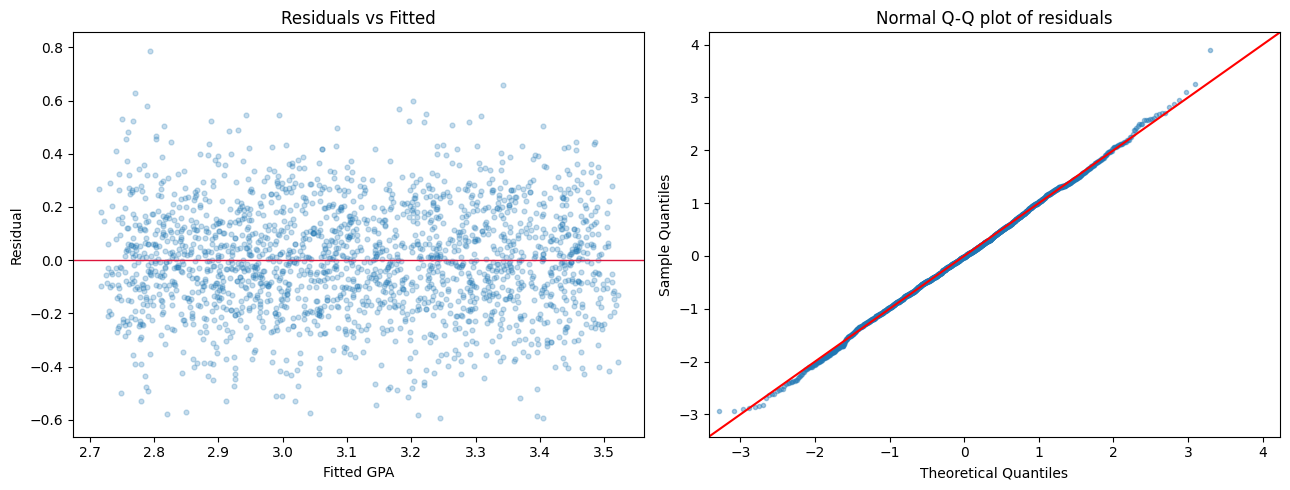

In [ ]:
fitted = m2.fittedvalues
resid  = m2.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(fitted, resid, alpha=0.25, s=12)
axes[0].axhline(0, color="crimson", lw=1)
axes[0].set_xlabel("Fitted GPA"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(resid, line="45", fit=True, ax=axes[1], markersize=3, alpha=0.4)
axes[1].set_title("Normal Q-Q plot of residuals")
plt.tight_layout(); plt.show()

### Residual diagnostics

We check the regression assumptions visually. In the **residuals-vs-fitted** plot, the
residuals form a structureless cloud centered on zero, with roughly constant vertical
spread across the full range of fitted GPA values (≈ 2.7–3.5) and no curvature or
fanning. This supports the **linearity** and **constant-variance (homoscedasticity)**
assumptions. In the **normal Q–Q plot**, the sample quantiles fall almost exactly along
the 45° reference line from the lower to the upper tail, indicating the residuals are
very close to **normally distributed**, with only negligible departure at the extreme
tails. These visual results are consistent with the model summary's built-in statistics
(skew ≈ 0.03, kurtosis ≈ 3.08, Prob(JB) = 0.654). The OLS assumptions are therefore well
satisfied, and the standard errors and p-values from the model can be trusted.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

X, y = life[PREDS].values, life["gpa"].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")

print("5-fold CV R2 per fold:", cv_r2.round(4))
print("Mean CV R2     = %.4f (sd %.4f)" % (cv_r2.mean(), cv_r2.std()))
print("In-sample R2   = %.4f" % m2.rsquared)

5-fold CV R2 per fold: [0.5495 0.487  0.5525 0.5199 0.5718]
Mean CV R2     = 0.5361 (sd 0.0296)
In-sample R2   = 0.5410


### Cross-validation

To evaluate how well the model predicts unseen data, we apply **5-fold cross-validation**.
The out-of-sample R² is stable across folds (0.487 to 0.572), with a mean of **0.536**
(sd ≈ 0.030). This is essentially identical to the in-sample R² of **0.541**, so there is
no meaningful drop in performance on held-out data. The model therefore **generalizes
well and shows no sign of overfitting** — expected, since it uses only four predictors on
2,000 observations. Together with the residual diagnostics above, this confirms that M2
is both a valid and a reliable model of GPA.

## 3. Coefficient Interpretation

We examine the estimated coefficients of the final model (M2), each with its standard
error, t-statistic, p-value, and 95% confidence interval. Because the day is a fixed
24-hour budget with **extracurricular hours as the reference**, each slope represents the
estimated change in GPA from reallocating one hour *out of extracurricular time and into*
that activity.

In [ ]:
coef_tbl = pd.DataFrame({
    "coef":    m2.params,
    "std_err": m2.bse,
    "t":       m2.tvalues,
    "p_value": m2.pvalues,
    "CI_low":  m2.conf_int()[0],
    "CI_high": m2.conf_int()[1],
}).round(4)
coef_tbl

,coef,std_err,t,p_value,CI_low,CI_high
Intercept,1.8274,0.0926,19.7338,0.0000,1.6458,2.0090
study_hours_per_day,0.1619,0.0050,32.0956,0.0000,0.1520,0.1718
sleep_hours_per_day,0.0029,0.0050,0.5870,0.5572,-0.0069,0.0128
social_hours_per_day,0.0088,0.0045,1.9538,0.0509,-0.0000,0.0177
physical_activity_hours_per_day,0.0075,0.0040,1.8931,0.0585,-0.0003,0.0153


In [ ]:
# Sanity check: prints every figure cited in the Section 4 write-up,
# pulled directly from the fitted model so text and output stay in sync.

print("=== Model fit ===")
print(f"n = {int(m2.nobs)} | R2 = {m2.rsquared:.3f} | adj R2 = {m2.rsquared_adj:.3f} "
      f"| F = {m2.fvalue:.1f} | F p-value = {m2.f_pvalue:.2e}")

print("\n=== Coefficients ===")
ci = m2.conf_int()
for name in m2.params.index:
    b, se, t, p = m2.params[name], m2.bse[name], m2.tvalues[name], m2.pvalues[name]
    lo, hi = ci.loc[name, 0], ci.loc[name, 1]
    pstr = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    print(f"{name:34s} beta = {b:7.3f} | SE = {se:.3f} | t = {t:7.2f} | {pstr} "
          f"| 95% CI [{lo:.3f}, {hi:.3f}]")

# Cross-validation figures (only if the CV cell has been run this session)
try:
    print("\n=== Cross-validation ===")
    print(f"Mean CV R2 = {cv_r2.mean():.3f} (sd {cv_r2.std():.3f}) | In-sample R2 = {m2.rsquared:.3f}")
except NameError:
    print("\n(Run the cross-validation cell first to print CV R2.)")

=== Model fit ===
n = 2000 | R2 = 0.541 | adj R2 = 0.540 | F = 587.8 | F p-value = 0.00e+00

=== Coefficients ===
Intercept                          beta =   1.827 | SE = 0.093 | t =   19.73 | p < 0.001 | 95% CI [1.646, 2.009]
study_hours_per_day                beta =   0.162 | SE = 0.005 | t =   32.10 | p < 0.001 | 95% CI [0.152, 0.172]
sleep_hours_per_day                beta =   0.003 | SE = 0.005 | t =    0.59 | p = 0.557 | 95% CI [-0.007, 0.013]
social_hours_per_day               beta =   0.009 | SE = 0.005 | t =    1.95 | p = 0.051 | 95% CI [-0.000, 0.018]
physical_activity_hours_per_day    beta =   0.007 | SE = 0.004 | t =    1.89 | p = 0.058 | 95% CI [-0.000, 0.015]

=== Cross-validation ===
Mean CV R2 = 0.536 (sd 0.030) | In-sample R2 = 0.541


### Interpreting the coefficients

Because extracurricular hours are the reference, each slope is the estimated change in
GPA from reallocating one hour *out of extracurricular time and into* that activity,
holding the rest fixed.

- **Study hours per day** (β = 0.162, SE = 0.005, t = 32.10, p < 0.001, 95% CI
  [0.152, 0.172]): the only large, clearly significant effect. Each hour shifted into
  studying is associated with an increase of about **0.16 GPA points**. The very large
  t-statistic and a narrow confidence interval far from zero make this a precise,
  reliable estimate.

- **Sleep hours per day** (β = 0.003, p = 0.557, 95% CI [−0.007, 0.013]): not
  significant. Relative to extracurricular time, shifting an hour into sleep has no
  detectable effect on GPA, and the confidence interval is centered near zero.

- **Social hours per day** (β = 0.009, p = 0.051, 95% CI [−0.000, 0.018]) and
  **physical activity hours per day** (β = 0.008, p = 0.059, 95% CI [−0.000, 0.015]):
  both sit just *above* the 0.05 threshold, so we treat them as **not statistically
  significant** at the 5% level. Their confidence intervals only barely include zero,
  hinting at a possible small positive association, but the evidence is too weak to
  conclude one exists.

- **Intercept** (1.827, 95% CI [1.646, 2.009]): not independently interpretable here,
  since "zero hours on every activity" lies outside the data — the five activities must
  sum to 24 hours for every student.

**Summary.** Of all the ways students divide their day, only time spent **studying** has
a clear, significant relationship with GPA. Given the fixed 24-hour budget, this is best
read as a *trade-off*: GPA gains come from moving time toward studying and away from other
activities, not from any independent benefit of sleep, socializing, or exercise.

## 4. Statistical Analysis & Results

To model GPA, we used linear regression (OLS) on the Student Lifestyle dataset, which has
2,000 students and is the only one of our datasets that includes GPA. One thing we had to
deal with is that the five daily activities (studying, sleeping, socializing,
extracurriculars, and physical activity) always add up to 24 hours per student. That means
more time on one activity has to come from another, so we couldn't just throw all five
into the model at once. We left extracurricular hours out as a baseline, so each
coefficient shows how GPA changes when a student moves an hour from extracurriculars into
that activity.

We tried three models: one with just study hours (M1), one that added sleep, social, and
physical activity hours (M2), and one that also added stress level (M3). The adjusted R²
barely moved between them (0.539, 0.540, 0.540), and M2 had the lowest AIC of the three,
so we went with M2. Basically, the extra terms in M3 made the model more complicated
without actually making it better.

M2 was significant overall (F(4, 1995) = 587.8, p < 0.001) and explained about 54% of the
variation in GPA (R² = 0.541). The big takeaway is that study hours was the only predictor
that really mattered (β = 0.162, p < 0.001, 95% CI [0.152, 0.172]). Every extra hour spent
studying was linked to about a 0.16 increase in GPA. Sleep (p = 0.557), social
(p = 0.051), and physical activity (p = 0.059) all came out not significant, with
confidence intervals that basically include zero, so we didn't find a real effect from
them.

We also checked that the model met the usual regression assumptions. The residuals versus
fitted plot looked like a random cloud around zero, which means the variance stays
constant, and the QQ plot had the points sitting right on the line, so the residuals are
roughly normal (the summary's Prob(JB) = 0.654 backs this up). To see how well the model
predicts new data, we ran cross validation with five folds. The out of sample R² was
0.536, almost the same as the in sample 0.541, so the model isn't overfitting and holds up
on data it hasn't seen.

Overall, our results show that GPA in this dataset is mostly driven by how much time
students spend studying. Since everyone only has 24 hours in a day, we think this is best
seen as a trade off: GPA goes up when students put more time into studying and less into
other things, not because sleep or exercise are bad for grades, but because that study
time has to come from somewhere.

---

## Conclusion

This project examined how sleep, stress, and study habits jointly relate to GPA using correlation analysis, hypothesis testing, and multiple linear regression. The dominant finding is that study time is by far the strongest predictor of GPA (β = 0.162, p < 0.001), while sleep, social, and physical activity hours were not significant at the 5% level. The model explained ~54% of GPA variance and generalized well under cross-validation (mean CV R² = 0.536). Interpreted through a time-allocation lens, GPA gains come from shifting time toward studying rather than from any independent benefit of sleep or reduced stress. Future work should examine sleep quality, longitudinal designs, and broader demographic samples.

---

## 8. Limitations

- **Dataset scope:** Both datasets are Kaggle-sourced with unknown sampling frames and may not generalize broadly. GPA was only available in one dataset, limiting the regression.
- **Self-report bias:** All variables are self-reported and subject to recall error and social desirability bias.
- **Cross-sectional design:** No causal claims can be made; high-achieving students may simply choose to study more.
- **Unmeasured confounders:** Major, course difficulty, employment status, and mental health history are absent.
- **Stress granularity:** Stress is recorded as a three-category ordinal variable, which likely obscures meaningful variation.

---

## 9. References

Curcio, G., Ferrara, M., & De Gennaro, L. (2006). Sleep loss, learning capacity and academic performance. *Sleep Medicine Reviews, 10*(5), 323–337.

Hartmann, M. E., & Prichard, J. R. (2018). Calculating the contribution of sleep problems to undergraduates' academic success. *Sleep Health, 4*(5), 463–471.

Hershner, S. D., & Chervin, R. D. (2014). Causes and consequences of sleepiness among college students. *Nature and Science of Sleep, 6*, 73–84.

Pascoe, M. C., Hetrick, S. E., & Parker, A. G. (2020). The impact of stress on students in secondary school and higher education. *International Journal of Adolescence and Youth, 25*(1), 104–112.

Student Stress Factors dataset: https://www.kaggle.com/datasets/rxnach/student-stress-factors-a-comprehensive-analysis

Student Lifestyle dataset: https://www.kaggle.com/datasets/steve1215rogg/student-lifestyle-dataset